importam tensorflow (pentru modelul cnn), matplotlib (pentru grafice)

In [7]:
import tensorflow as tf
import os

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import helpers

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # opreste ceva mesaje de warning
os.environ["XLA_FLAGS"] = (
    "--xla_gpu_cuda_data_dir=/usr/local/cuda"  # foloseste cuda pentru antrenare
)

ca sa aratam capabilitatile retelelor neuronale convolutionale (CNN), comparam cu o implementare naiva a unei retele FFNN (feed-forward).

din cauza ca reteaua FF nu intelege date sub forma de grid (2D) trebuie sa facem FLATTEN la date din 32 (width) x 32 (height) x 3 (canale) intr-o singura lista 1D de 3072 de input-uri

In [8]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
ffnn_model = models.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),  # aplatizeaza imaginile
        layers.Dense(1024, activation="relu"),  # de ce??
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),  # softmax pentru clasificare
    ]
)

ffnn_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False
)

ffnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,676,682 (14.03 MB)

 Trainable params: 3,676,682 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

observam numarul de parametrii, 3.6M reprezinta fiecare pixel din imagine conectat la fiecare alt pixel din imagine (crazy)

(atata matematica si tot nu o sa depaseasca 50% accuracy)

In [10]:
history_ffnn_model = ffnn_model.fit(
    X_train, y_train, epochs=10, validation_data=(X_test, y_test)
)

Epoch 1/10


W0000 00:00:1777127797.021600  373065 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.106926  373679 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.109729  373678 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.112495  373684 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.115665  373687 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.116967  373682 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777127797.130872  373679 gpu_kernel_to_blob_pass.cc:190] Failed to co

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3298 - loss: 1.8638 - val_accuracy: 0.3937 - val_loss: 1.6909
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3978 - loss: 1.6754 - val_accuracy: 0.4146 - val_loss: 1.6232
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4245 - loss: 1.6005 - val_accuracy: 0.4385 - val_loss: 1.5626
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4479 - loss: 1.5423 - val_accuracy: 0.4349 - val_loss: 1.5613
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4646 - loss: 1.4996 - val_accuracy: 0.4541 - val_loss: 1.5308
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4752 - loss: 1.4711 - val_accuracy: 0.4621 - val_loss: 1.5064
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4813 - loss: 1.4444 - val_accuracy: 0.4668 - val_loss: 1.4979
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4916 - loss: 1.4214 - val

ploturi

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


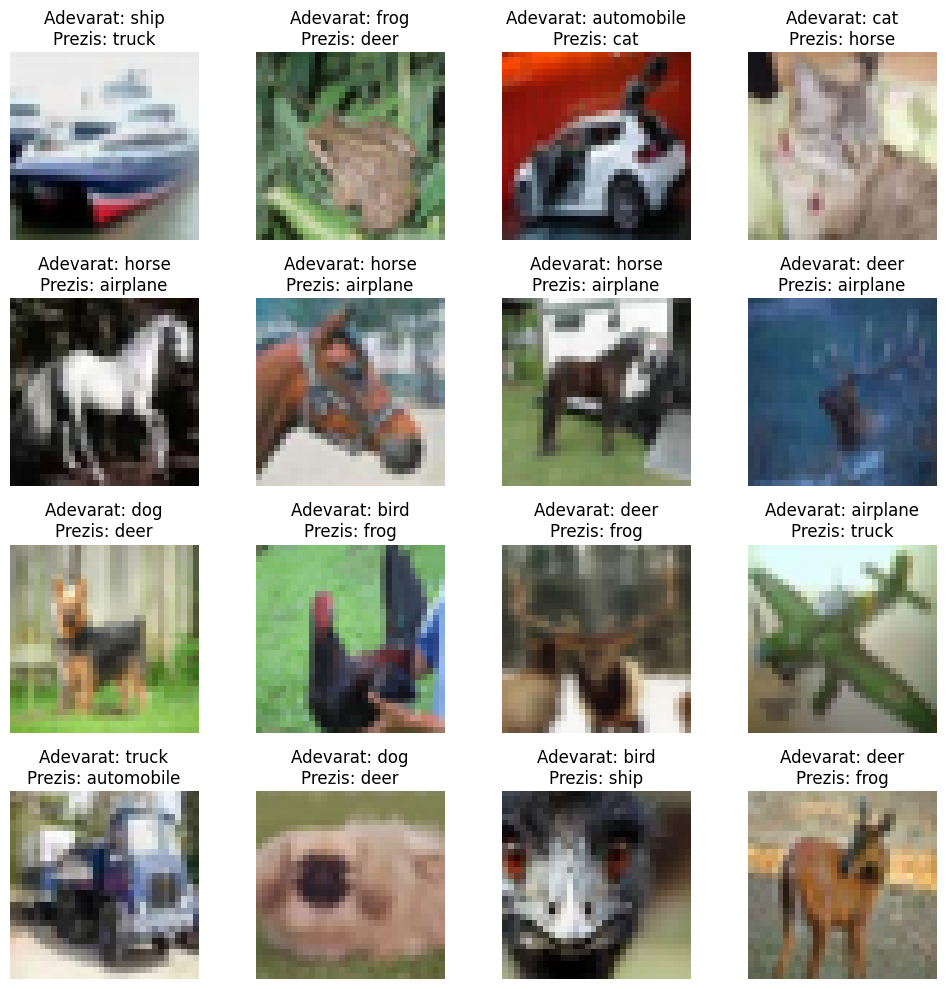

In [11]:
helpers.plot_misclassification(ffnn_model, X_test, y_test, class_names, num_images=16)

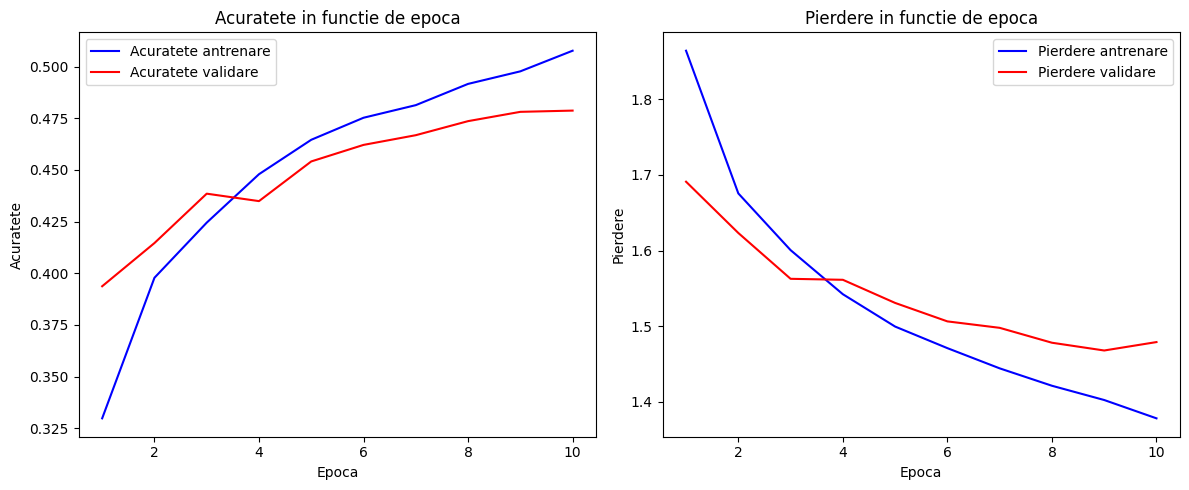

In [12]:
helpers.plot_learning_curve(history_ffnn_model)

*f1-score*: 


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

    airplane       0.46      0.58      0.51      1000
  automobile       0.58      0.60      0.59      1000
        bird       0.41      0.32      0.36      1000
         cat       0.32      0.40      0.35      1000
        deer       0.48      0.33      0.39      1000
         dog       0.45      0.33      0.38      1000
        frog       0.54      0.49      0.51      1000
       horse       0.55      0.51      0.53      1000
        ship       0.50      0.71      0.58      1000
       truck       0.54      0.51      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.47     10000
weighted avg       0.48      0.48      0.47     10000



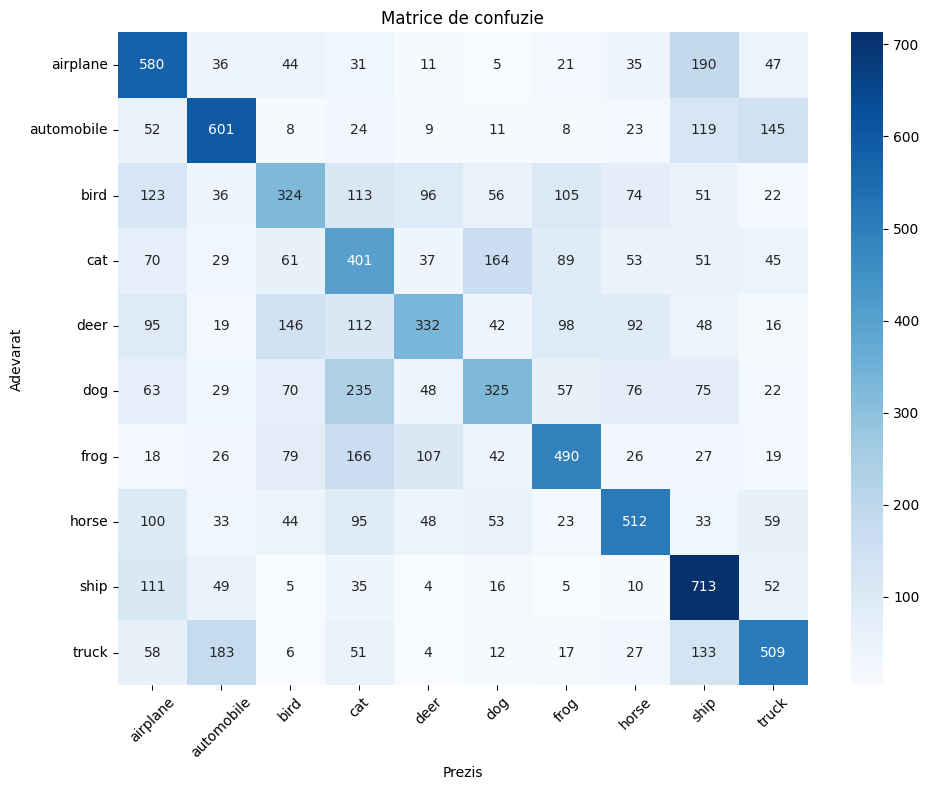

In [13]:
helpers.plot_confusion_matrix(ffnn_model, X_test, y_test, class_names)